# WKBeam–LUKE coupled simulation setup

This notebook creates the `input/` folder for a WKBeam campaign that is driven
by the BOBAFETT/LUKE optimisation loop.  It does **not** create `output/`,
`plots/`, binning configs, or run scripts — those are generated per-iteration
by `wkb_make_configs_ed` and `wkb_setup_dirs_ed` inside MATLAB.

**What gets created**

```
<campaign_root>/
  input/
    topfile, ne.dat, Te.dat, nefluct.dat   ← copied from data_folder
    RayTracing_template.txt                ← geometry + equilibriumdirectory patched;
                                              output_dir / qlabs_* left as placeholders
    fluct_amplitude.py
    Lperp_rhos_model.py
```

**Workflow**

1. Point to the prepared data folder → `load_ec_params` reads the ECparams file,
   `copy_input_files` copies equilibrium files into `input/`
2. Generate `input/RayTracing_template.txt` — geometry comes from ECparams;
   QL-specific fields (`qlabs_maxwellian`, `qlabs_edf_file`, `output_dir`) are
   left as placeholders for `wkb_make_configs_ed` to patch at runtime
3. Generate the scattering model files `fluct_amplitude.py` and `Lperp_rhos_model.py`

In [23]:
import os
import sys
import numpy as np

WKBEAM_DIR = '/home/devlamin/WanKenoBEAM'
if WKBEAM_DIR not in sys.path:
    sys.path.insert(0, WKBEAM_DIR)

from Wrapper.wrapper_aux import SimulationSetup, load_ec_params

## 1 — Campaign definition

Point to the prepared data folder, load the EC launcher parameters, create the
campaign `input/` directory, and copy equilibrium files.

In [24]:
# --- Data source ----------------------------------------------------------
campaign_root = '/home/devlamin/EC23_WKBeam_sims/TCV_88619_1.25_Fluct_Finalrun'
data_folder   = '/home/devlamin/matlab/wkbeam_input_prep/88619_1.25'
vesselfile    = '/home/devlamin/WanKenoBEAM/Tools/PlotData/PlotVessel/88612_vessel.mat'

shot = 88619
time = 1.25
tag  = 'Fluct_Finalrun'
fluct = True
nrays = 1000

# --- Read EC launcher parameters (one entry per active launcher) ----------
launcher_list = load_ec_params(data_folder)

# --- Tokamak geometry (for SimulationSetup) --------------------------------
rmaj = 88.   # [cm]
rmin = 25.   # [cm]

# --- One campaign root per launcher (BOBAFETT convention) -----------------
# Each launcher lives in its own campaign root: <base>_<launcher_name>/
# The MATLAB QL_create_PARAMS.m must point run_inputPath to these same folders.
sims = []
for ec_params, InputPower, launcher_name in launcher_list:
    sim_dir = f'{campaign_root}_{launcher_name}'
    sim = SimulationSetup(
        sim_dir    = sim_dir,
        sim_name   = launcher_name,
        rmaj       = rmaj,
        rmin       = rmin,
        InputPower = InputPower,
        tag        = tag,
    )
    sim.create_input_dir()
    sim.copy_input_files(data_folder)
    sims.append((sim, ec_params))

Loaded ECparams: launcher=L4, freq=84.0 GHz, InputPower=0.882 MW
Copied to /home/devlamin/EC23_WKBeam_sims/TCV_88619_1.25_Fluct_Finalrun_L4/input/: Te.dat, ne.dat, nefluct.dat, topfile


## 2 — RayTracing template

Writes `input/RayTracing_template.txt` using `RayTracing_QLabs.txt` as base.
Launcher geometry and `equilibriumdirectory` are patched now.  
The following fields are left as placeholders for `wkb_make_configs_ed`:
- `output_dir` / `output_filename` → set to `iter_N/output/` at runtime
- `qlabs_maxwellian` → `True` at iter 0, `False` thereafter
- `qlabs_edf_file` → path to the current EDF at runtime

In [25]:
for sim, ec_params in sims:
    sim.make_raytracing_template(
        sigma      = -1.,      # mode: -1 = X-mode, +1 = O-mode
        nmbrRays   = nrays,
        vesselfile = vesselfile,
        **ec_params,           # freq, beamwidths, curvature radii, position, angles
        scattering = fluct,
    )

Generating input/RayTracing_template.txt ...
  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88619_1.25_Fluct_Finalrun_L4/input/RayTracing_template.txt


## 3 — Scattering model files

Generate the fluctuation amplitude and perpendicular correlation length Python
files into `input/`.  WKBeam loads these at runtime via the string keys
`'fluct_amplitude'` and `'Lperp_rhos_model'` set in the template.

In [26]:
for sim, _ in sims:
    sim.make_fluct_amplitude(
        ballooning = 0.5,   # 1 = isotropic, 0 = fully ballooned
    )
    sim.make_lperp_model(
        mu      = 2.0,   # deuterium
        Z       = 1.0,
        epsilon = 0.3,   # minimum Lperp [cm]
        factor  = 7.4,   # Lperp = factor * rho_s  (GBS calibration)
    )

  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88619_1.25_Fluct_Finalrun_L4/input/fluct_amplitude.py
  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88619_1.25_Fluct_Finalrun_L4/input/Lperp_rhos_model.py


## 4 — Inspect fluct_amplitude profile

Run the generated `fluct_amplitude.py` to visualise the fluctuation amplitude
profile before launching the BOBAFETT optimisation.

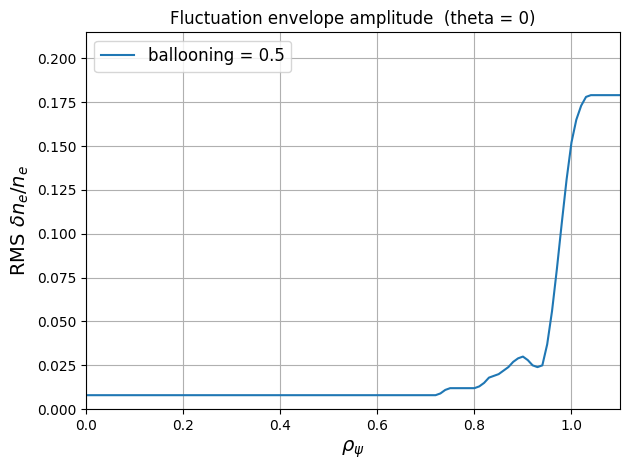

In [27]:
%matplotlib inline
import runpy

for sim, _ in sims:
    _fluct_path = os.path.join(sim.sim_dir, 'input', 'fluct_amplitude.py')
    runpy.run_path(_fluct_path, run_name='__main__')